In [1]:
import requests
import json
import base64
from IPython.display import display, JSON, Image

BASE_URL = "http://localhost:10011"

## Agent Card

In [2]:
resp = requests.get(f"{BASE_URL}/.well-known/agent-card.json")
resp.raise_for_status()
resp.json()

{'name': 'Chart Generator Agent',
 'description': 'Generate charts from structured CSV-like data input.',
 'supportedInterfaces': [{'url': 'http://localhost:10011/'}],
 'version': '1.0.0',
 'capabilities': {'streaming': False},
 'defaultInputModes': ['text', 'text/plain', 'image/png'],
 'defaultOutputModes': ['text', 'text/plain', 'image/png'],
 'skills': [{'id': 'chart_generator',
   'name': 'Chart Generator',
   'description': 'Generate a chart based on CSV-like data',
   'tags': ['generate image'],
   'examples': ['Generate a chart: Jan,1000 Feb,2000 Mar,1500']}],
 'preferredTransport': '',
 'protocolVersion': '0.3',
 'url': 'http://localhost:10011/'}

## Send Message & Render Chart

In [3]:
payload = {
    "jsonrpc": "2.0",
    "id": "1",
    "method": "SendMessage",
    "params": {
        "message": {
            "role": "ROLE_USER",
            "parts": [
                {"text": "Generate a chart of revenue: Jan,1000\nFeb,2000\nMar,1500"}
            ],
            "messageId": "msg-001"
        }
    }
}

resp = requests.post(BASE_URL, json=payload)
resp.raise_for_status()
result = resp.json()


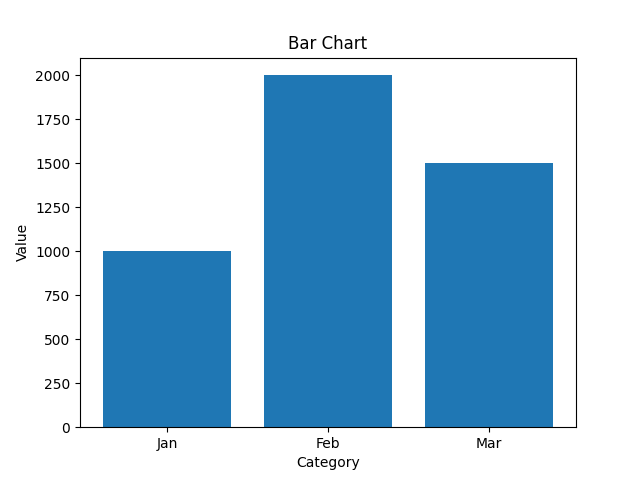

In [4]:

if "error" in result:
    print("Error:", json.dumps(result["error"], indent=2))
else:
    # Navigate to the raw bytes field in the first artifact's first part
    artifacts = result["result"]['task']["artifacts"]
    for artifact in artifacts:
        for part in artifact["parts"]:
            if "raw" in part:
                image_bytes = base64.b64decode(part["raw"])
                display(Image(data=image_bytes))
            elif "text" in part:
                print(part["text"])